# Exploration intégrée — Benchmark KG Juridique FR

**Sources de données :**
1. **Judilibre** (local, JSONL) — 1,13 M décisions CC/CA/TJ
2. **Les-Audits-Affaires** (HuggingFace) — 2 670 cas, 9 codes juridiques FR
3. **BSARD** (HuggingFace API) — 22 600+ articles, 1 100 questions FR
4. **M6 Gold Standard** (local) — 5 cas d'interprétation d'arrêt

**Objectif :** explorer, croiser et visualiser ces 4 sources pour alimenter la conception du benchmark.

In [1]:
# Installation des dépendances manquantes dans le kernel
import subprocess, sys

def pip_install(package):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

required = ["rich", "pydantic", "pyarrow", "requests", "huggingface_hub", "datasets"]
for pkg in required:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installation de {pkg}...")
        pip_install(pkg)

print("Dépendances OK")

Installation de huggingface_hub...



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Installation de datasets...
Dépendances OK



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# Nos loaders
from loaders.judilibre import iter_decisions, load_decisions, search_decisions, extract_zones
from loaders.bsard import load_corpus_rows, load_questions_rows
from m6_mvp.gold_cases import get_all_cases

print("Imports OK")

Imports OK


---
## 1. Judilibre — Vue d'ensemble

Échantillon de 1 000 décisions par juridiction pour profiler le schéma.

In [3]:
# Charger un échantillon par juridiction (enrichi)
SAMPLE = 1000

samples = {}
for jur in ("CC", "CA", "TJ"):
    samples[jur] = load_decisions(jur, enriched=True, n=SAMPLE)
    print(f"{jur}: {len(samples[jur])} décisions chargées — colonnes: {list(samples[jur].columns)}")

print(f"\nTotal échantillon: {sum(len(df) for df in samples.values()):,} décisions")

CC: 1000 décisions chargées — colonnes: ['summary', 'jurisdiction', 'numbers', 'location', 'formation', 'type', 'decision_date', 'themes', 'number', 'solution', 'ecli', 'chamber', 'solution_alt', 'publication', 'files', 'id', 'bulletin', 'update_datetime', 'decision_datetime', 'zones', 'forward', 'contested', 'update_date', 'nac', 'rapprochements', 'visa', 'particularInterest', 'timeline', 'to_be_deleted', 'text', 'partial', 'text_highlight', 'titlesAndSummaries', 'legacy', 'codes', 'articles', 'code_article_pairs']
CA: 1000 décisions chargées — colonnes: ['summary', 'jurisdiction', 'numbers', 'location', 'formation', 'type', 'decision_date', 'themes', 'number', 'solution', 'ecli', 'chamber', 'solution_alt', 'publication', 'files', 'id', 'bulletin', 'update_datetime', 'decision_datetime', 'zones', 'forward', 'contested', 'update_date', 'nac', 'rapprochements', 'visa', 'particularInterest', 'timeline', 'to_be_deleted', 'text', 'partial', 'text_highlight', 'titlesAndSummaries', 'legacy',

/var/folders/zz/y6p01ncd2z9_ty6kfx1zk1mh0000gn/T/ipykernel_81345/369820947.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


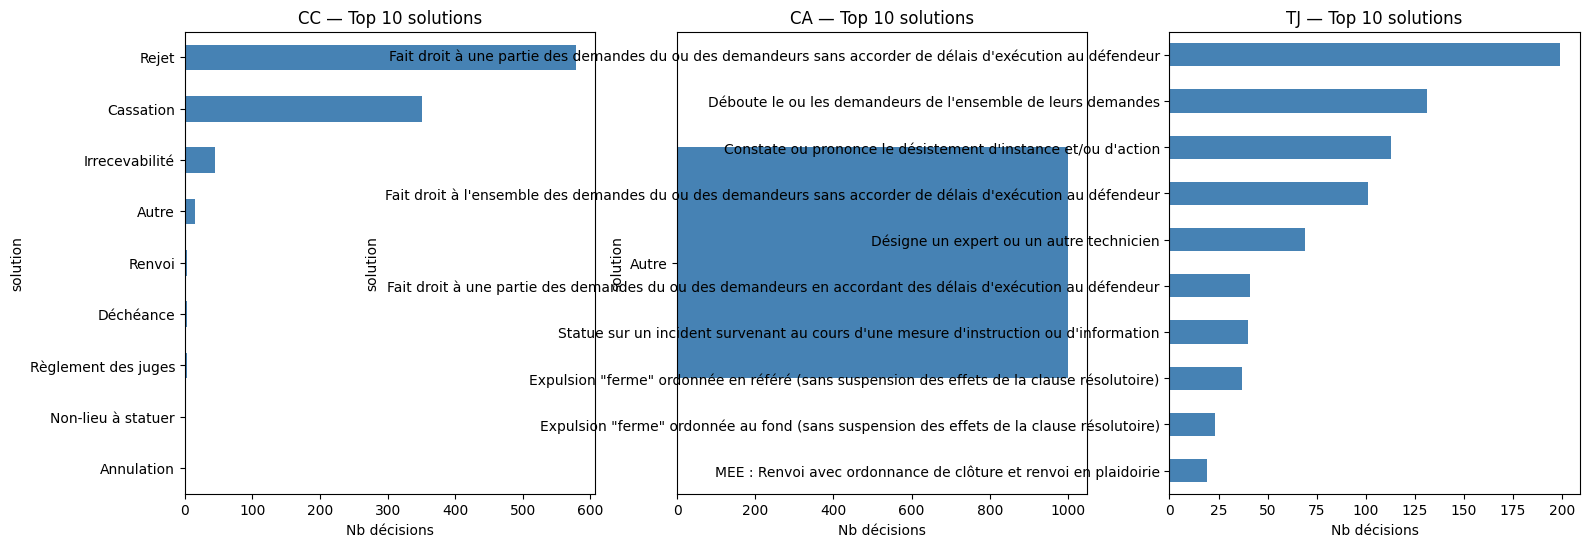

In [4]:
# Distribution des solutions par juridiction
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (jur, df) in zip(axes, samples.items()):
    counts = df["solution"].value_counts().head(10)
    counts.plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"{jur} — Top 10 solutions")
    ax.set_xlabel("Nb décisions")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

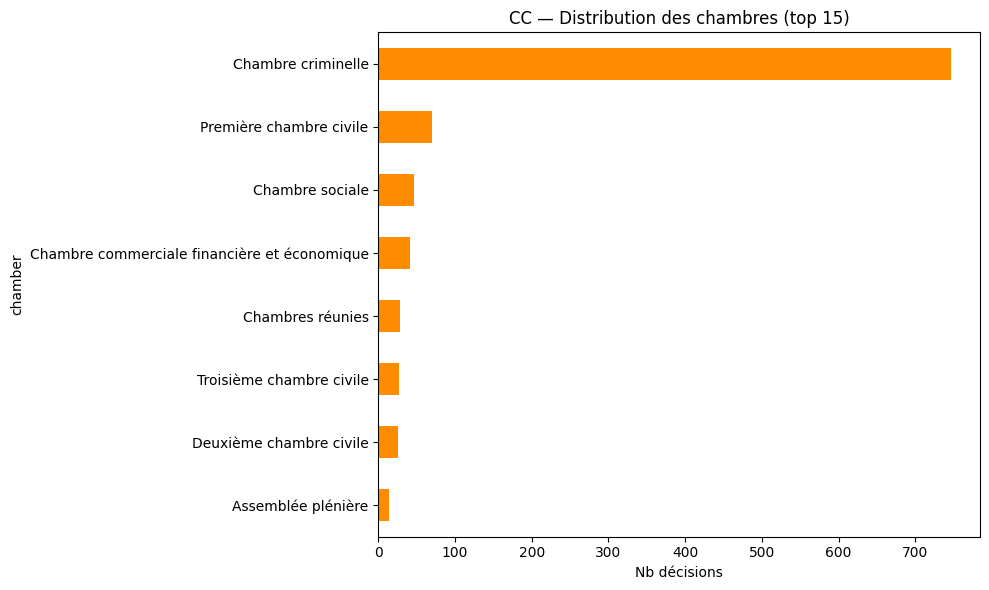

In [5]:
# Distribution des chambres (CC uniquement — les plus informatives)
cc = samples["CC"]
chamber_counts = cc["chamber"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
chamber_counts.plot.barh(ax=ax, color="darkorange")
ax.set_title("CC — Distribution des chambres (top 15)")
ax.set_xlabel("Nb décisions")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Taux de remplissage (%) par juridiction et champ :
    summary  themes  visa  rapprochements  zones  articles  codes  code_article_pairs
CC     98.1    98.8  58.7             3.4    0.0      94.8   50.8                40.6
CA      0.0   100.0  34.4             0.2    0.0      99.9   96.6                94.6
TJ      0.0     0.0   0.0             0.0   97.5      97.8   97.5                88.1


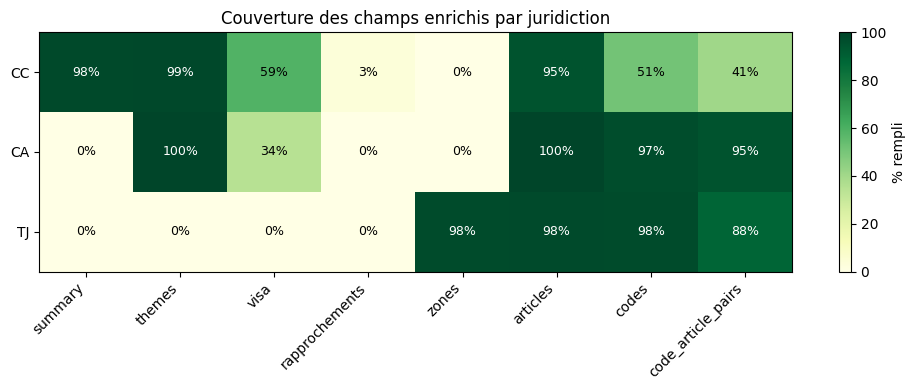

In [6]:
# Disponibilité des zones structurées et des champs enrichis
def check_field_coverage(df, fields):
    """Taux de remplissage de chaque champ."""
    stats = {}
    for f in fields:
        if f not in df.columns:
            stats[f] = 0.0
            continue
        filled = df[f].apply(lambda v: v is not None and v != "" and v != [] and v != {})
        stats[f] = filled.mean() * 100
    return stats

fields_to_check = [
    "summary", "themes", "visa", "rapprochements",
    "zones", "articles", "codes", "code_article_pairs",
]

coverage_data = {}
for jur, df in samples.items():
    coverage_data[jur] = check_field_coverage(df, fields_to_check)

coverage_df = pd.DataFrame(coverage_data).T
print("Taux de remplissage (%) par juridiction et champ :")
print(coverage_df.round(1).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(coverage_df.values, cmap="YlGn", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(coverage_df.columns)))
ax.set_xticklabels(coverage_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(coverage_df.index)))
ax.set_yticklabels(coverage_df.index)
for i in range(len(coverage_df.index)):
    for j in range(len(coverage_df.columns)):
        val = coverage_df.values[i, j]
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=9,
                color="white" if val > 60 else "black")
plt.colorbar(im, label="% rempli")
ax.set_title("Couverture des champs enrichis par juridiction")
plt.tight_layout()
plt.show()

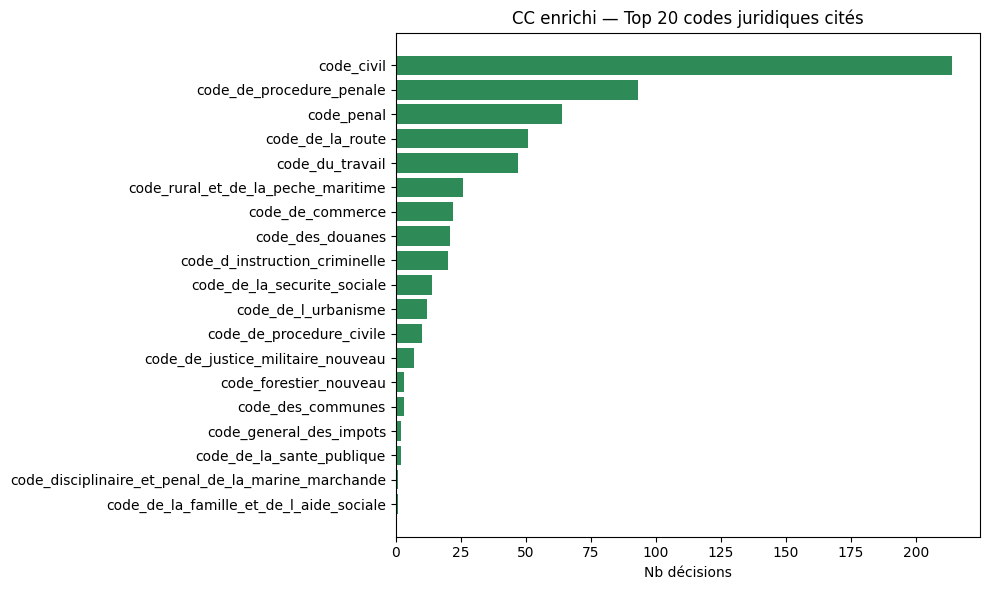

In [7]:
# Distribution des codes juridiques (version enrichie, CC)
code_counter = Counter()
for _, row in cc.iterrows():
    codes = row.get("codes")
    if codes and isinstance(codes, list):
        for c in codes:
            code_counter[c] += 1

if code_counter:
    top_codes = code_counter.most_common(20)
    labels, values = zip(*top_codes)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(labels)), values, color="seagreen")
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_title("CC enrichi — Top 20 codes juridiques cités")
    ax.set_xlabel("Nb décisions")
    plt.tight_layout()
    plt.show()
else:
    print("Pas de champ 'codes' renseigné dans l'échantillon")

---
## 2. Les-Audits-Affaires

Dataset HuggingFace `legmlai/les-audits-affaires` — 2 670 cas, 9 codes juridiques FR, 5 dimensions (Action, Délai, Documents, Impact, Conséquences).

In [8]:
from loaders.les_audits import load_les_audits

audits_df = load_les_audits()
print(f"Shape: {audits_df.shape}")
print(f"Colonnes: {list(audits_df.columns)}")
print(f"\nPremier cas:")
for k, v in audits_df.iloc[0].items():
    v_str = str(v)
    if len(v_str) > 200:
        v_str = v_str[:200] + "..."
    print(f"  {k}: {v_str}")

Shape: (2658, 27)
Colonnes: ['id', 'question', 'action_requise', 'delai_legal', 'documents_obligatoires', 'impact_financier', 'consequences_non_conformite', 'persona_id', 'persona_name', 'persona_role', 'persona_sector', 'persona_company', 'persona_experience', 'persona_age_range', 'persona_city', 'region', 'scenario_type', 'difficulty_level', 'use_case_id', 'use_case_title', 'legal_framework', 'reference_article_number', 'reference_article_content', 'reference_article_title', 'industry_sectors', 'target_audiences', 'created_at']

Premier cas:
  id: fr_qa_000049
  question: Je souhaiterais comprendre précisément les étapes pour résilier un contrat commercial sans être en défaut, surtout s'il y a une clause de tacite reconduction.
  action_requise: Informer l'autre partie de la résiliation par lettre recommandée avec accusé de réception parce que l'article L. 136-1 du Code de la consommation impose une notification explicite pour éviter la tacit...
  delai_legal: Respecter un préavis ra

In [9]:
# Distribution par domaine juridique (ou colonne catégorielle)
category_col = None
for candidate in ("category", "domain", "code", "law_code", "juridical_domain"):
    if candidate in audits_df.columns:
        category_col = candidate
        break

if category_col:
    fig, ax = plt.subplots(figsize=(10, 5))
    counts = audits_df[category_col].value_counts()
    counts.plot.barh(ax=ax, color="coral")
    ax.set_title(f"Les-Audits-Affaires — Distribution par {category_col}")
    ax.set_xlabel("Nb cas")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Aucune colonne catégorielle identifiée")
    print("Colonnes disponibles:", list(audits_df.columns))

Aucune colonne catégorielle identifiée
Colonnes disponibles: ['id', 'question', 'action_requise', 'delai_legal', 'documents_obligatoires', 'impact_financier', 'consequences_non_conformite', 'persona_id', 'persona_name', 'persona_role', 'persona_sector', 'persona_company', 'persona_experience', 'persona_age_range', 'persona_city', 'region', 'scenario_type', 'difficulty_level', 'use_case_id', 'use_case_title', 'legal_framework', 'reference_article_number', 'reference_article_content', 'reference_article_title', 'industry_sectors', 'target_audiences', 'created_at']


In [10]:
# Distribution des longueurs de texte dans Les-Audits
text_cols = [c for c in audits_df.columns if audits_df[c].dtype == "object"]
# Chercher les colonnes les plus longues (probablement la question et la réponse)
col_avg_len = {}
for c in text_cols:
    avg = audits_df[c].dropna().apply(len).mean()
    col_avg_len[c] = avg

# Top 5 colonnes textuelles les plus longues
top_text = sorted(col_avg_len.items(), key=lambda x: -x[1])[:5]
print("Colonnes textuelles principales (par longueur moyenne) :")
for col, avg in top_text:
    print(f"  {col}: {avg:.0f} chars en moyenne")

Colonnes textuelles principales (par longueur moyenne) :
  reference_article_content: 1783 chars en moyenne
  action_requise: 253 chars en moyenne
  consequences_non_conformite: 238 chars en moyenne
  documents_obligatoires: 232 chars en moyenne
  impact_financier: 225 chars en moyenne


---
## 3. BSARD — Belgian Statutory Article Retrieval

Premier benchmark de retrieval juridique en français. 22 600+ articles de loi belge, ~1 100 questions annotées par 6 juristes.

In [11]:
# Charger corpus et questions BSARD
bsard_corpus = load_corpus_rows(n=100)
print(f"BSARD corpus: {bsard_corpus.shape}")
print(f"Colonnes: {list(bsard_corpus.columns)}")

try:
    bsard_questions = load_questions_rows(split="test", n=100)
    print(f"\nBSARD questions (test): {bsard_questions.shape}")
    print(f"Colonnes: {list(bsard_questions.columns)}")
except Exception as e:
    bsard_questions = pd.DataFrame()
    print(f"\nQuestions inaccessibles: {e}")

BSARD corpus: (100, 12)
Colonnes: ['id', 'reference', 'article', 'law_type', 'code', 'book', 'part', 'act', 'chapter', 'section', 'subsection', 'description']

BSARD questions (test): (100, 6)
Colonnes: ['id', 'category', 'subcategory', 'question', 'extra_description', 'article_ids']


In [12]:
# Exemples d'articles et questions BSARD
if len(bsard_corpus) > 0:
    print("=== Exemple d'article BSARD ===")
    first = bsard_corpus.iloc[0]
    for k, v in first.items():
        v_str = str(v)
        if len(v_str) > 200:
            v_str = v_str[:200] + "..."
        print(f"  {k}: {v_str}")

if len(bsard_questions) > 0:
    print("\n=== Exemple de question BSARD ===")
    first_q = bsard_questions.iloc[0]
    for k, v in first_q.items():
        v_str = str(v)
        if len(v_str) > 200:
            v_str = v_str[:200] + "..."
        print(f"  {k}: {v_str}")

=== Exemple d'article BSARD ===
  id: 1
  reference: Art. 1.1.1, Code Bruxellois de l'Air, du Climat et de la Maîtrise de l'Energie (Livre 1er, Titre 1er)
  article: Le présent Code règle une matière visée à l'article 39 de la Constitution.
  law_type: regional
  code: Code Bruxellois de l'Air, du Climat et de la Maîtrise de l'Energie
  book: Dispositions communes
  part: None
  act: Généralités
  chapter: None
  section: None
  subsection: None
  description: Dispositions communes, Généralités

=== Exemple de question BSARD ===
  id: 775
  category: Logement
  subcategory: Insalubrité en Wallonie
  question: Quels sont les critères communaux d'insalubrité ?
  extra_description: None
  article_ids: 12024


---
## 4. M6 Gold Standard — 5 cas d'interprétation d'arrêt

Nos 5 cas gold standard avec de vraies décisions Judilibre (Cour de cassation).

In [13]:
# Charger les 5 cas gold M6
cases = get_all_cases()
print(f"{len(cases)} cas gold M6 chargés\n")

# Tableau récapitulatif
m6_summary = pd.DataFrame([{
    "ID": c.id,
    "Spécialisation": c.specialisation.value,
    "Difficulté": c.difficulty.value,
    "Juridiction": c.decision.juridiction.value,
    "Date": str(c.decision.date),
    "N° pourvoi": c.decision.numero,
    "Sens": c.gold.sens_arret.value,
    "Favorable": c.gold.is_favorable,
    "Relevance": c.gold.relevance,
    "Texte (chars)": len(c.decision.full_text),
    "Synthétique": c.decision.is_synthetic,
} for c in cases])

m6_summary

5 cas gold M6 chargés



,ID,Spécialisation,Difficulté,Juridiction,Date,N° pourvoi,Sens,Favorable,Relevance,Texte (chars),Synthétique
0,M6-JP-001,Droit Social,easy,CC,2020-01-15,18-14.177,cassation,True,0.90,23830,False
1,M6-JP-002,Droit Civil,medium,CC,2018-03-08,17-10.315,rejet,True,0.85,13140,False
2,M6-JP-003,Droit de la Famille,medium,CC,2020-09-02,19-11.928,rejet,False,0.80,19367,False
3,M6-JP-004,Droit Commercial,trap,CC,2018-01-17,16-22.253,cassation,False,0.20,20730,False
4,M6-JP-005,Droit Pénal,hard,CC,2018-01-30,17-81.706,rejet,False,0.92,18302,False


In [14]:
# Détail d'un cas : structure de la décision réelle
case_ex = cases[0]  # Droit social — liberté d'expression
print(f"=== {case_ex.id} — {case_ex.specialisation.value} ===")
print(f"Question: {case_ex.question}")
print(f"Client: {case_ex.case.client_position.value}")
print(f"\nDécision: Cass. {case_ex.decision.chambre}, {case_ex.decision.date}, n° {case_ex.decision.numero}")
print(f"  Sens: {case_ex.gold.sens_arret.value}")
print(f"  Favorable: {case_ex.gold.is_favorable}")
print(f"  Relevance: {case_ex.gold.relevance}")
print(f"\nPrincipes extraits:")
for p in case_ex.gold.principles_extracted:
    print(f"  - {p}")
print(f"\nTransfert:")
print(f"  {case_ex.gold.transfer_reasoning[:300]}...")

=== M6-JP-001 — Droit Social ===
Question: Le licenciement pour faute grave est-il valable dans ce contexte ?
Client: defense

Décision: Cass. Chambre sociale, 2020-01-15, n° 18-14.177
  Sens: cassation
  Favorable: True
  Relevance: 0.9

Principes extraits:
  - La liberté d'expression du salarié est protégée (art. L. 1121-1 C. trav.)
  - Seules des restrictions justifiées par la tâche et proportionnées au but sont admises
  - Des propos critiques en interne ne suffisent pas à constituer une faute grave
  - La qualification de faute grave exige de caractériser précisément l'abus

Transfert:
  Cette décision s'applique directement au dossier : le salarié a diffusé un email critique en interne, sans diffamation apparente. La Cour de cassation exige que l'employeur caractérise un abus (propos injurieux, diffamatoires ou excessifs) pour justifier un licenciement, ce qui semble absent ici. Ar...


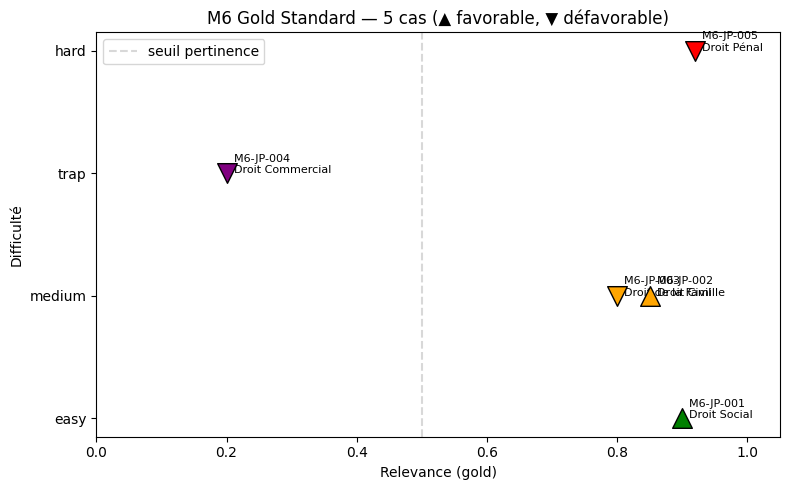

In [15]:
# Visualisation des 5 cas gold : relevance vs difficulté
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"easy": "green", "medium": "orange", "hard": "red", "trap": "purple"}
for c in cases:
    color = colors.get(c.difficulty.value, "gray")
    marker = "^" if c.gold.is_favorable else "v"
    ax.scatter(c.gold.relevance, c.difficulty.value, c=color, marker=marker, s=200, 
               edgecolors="black", zorder=5)
    ax.annotate(f"  {c.id}\n  {c.specialisation.value}", 
                (c.gold.relevance, c.difficulty.value), fontsize=8)

ax.set_xlabel("Relevance (gold)")
ax.set_ylabel("Difficulté")
ax.set_title("M6 Gold Standard — 5 cas (▲ favorable, ▼ défavorable)")
ax.set_xlim(0, 1.05)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.3, label="seuil pertinence")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Croisements entre sources

### 5.1 Couverture thématique : Judilibre × Les-Audits

Quels domaines de Les-Audits sont les mieux représentés dans nos décisions Judilibre ?

In [16]:
# Mapping Les-Audits catégories → codes Judilibre enrichis
# Les-Audits utilise des codes juridiques FR ; Judilibre enrichi a un champ "codes"

# D'abord, identifier le format des catégories Les-Audits
if category_col:
    audits_categories = audits_df[category_col].unique().tolist()
    print("Catégories Les-Audits:")
    for cat in sorted(audits_categories):
        print(f"  - {cat} ({(audits_df[category_col] == cat).sum()} cas)")
    
    print(f"\nCodes Judilibre enrichi (CC, top 15):")
    for code, cnt in code_counter.most_common(15):
        print(f"  - {code} ({cnt})")
else:
    print("Pas de colonne catégorielle dans Les-Audits")

Pas de colonne catégorielle dans Les-Audits


### 5.2 Longueur des textes comparés

Comparaison des distributions de longueur de texte entre les 3 sources.

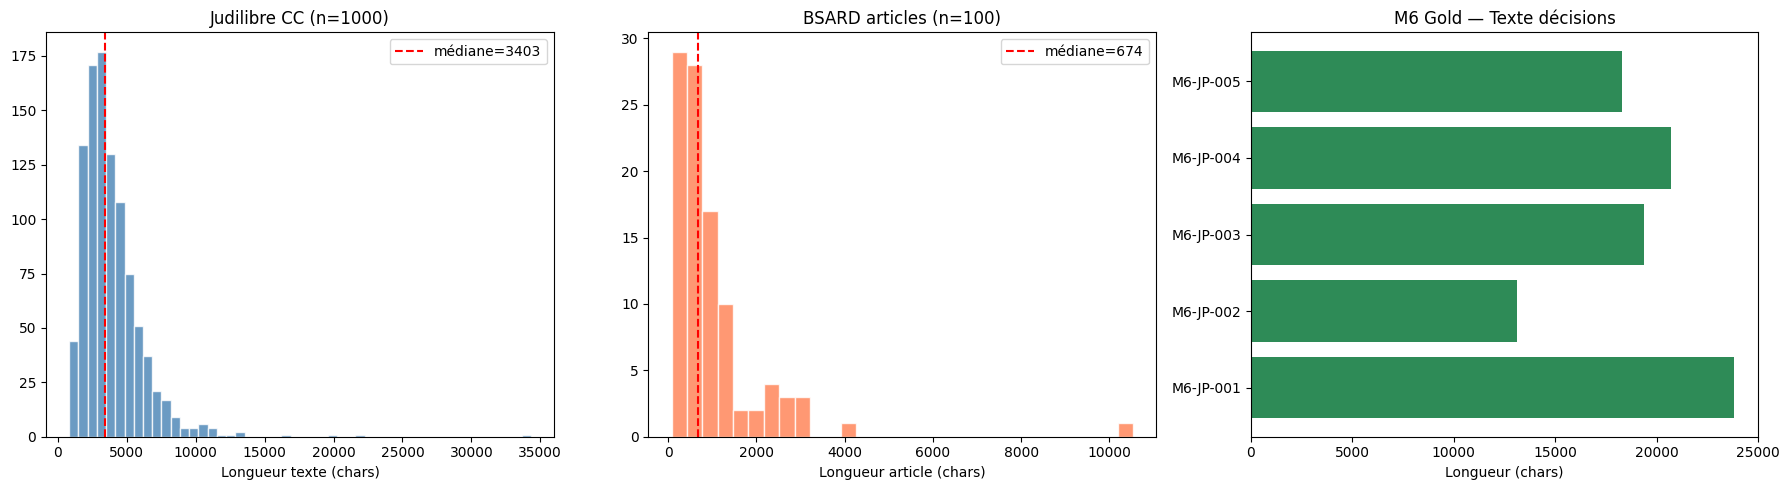


Médiane Judilibre CC: 3403 chars
Médiane BSARD articles: 674 chars
Moyenne M6 décisions: 19074 chars


In [17]:
# Distribution des longueurs de texte — Judilibre vs BSARD vs M6
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Judilibre CC
text_lens_cc = cc["text"].dropna().apply(len)
axes[0].hist(text_lens_cc, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title(f"Judilibre CC (n={len(text_lens_cc)})")
axes[0].set_xlabel("Longueur texte (chars)")
axes[0].axvline(text_lens_cc.median(), color="red", linestyle="--", label=f"médiane={text_lens_cc.median():.0f}")
axes[0].legend()

# BSARD corpus
if "text" in bsard_corpus.columns:
    bsard_text_col = "text"
elif "article" in bsard_corpus.columns:
    bsard_text_col = "article"
else:
    bsard_text_col = bsard_corpus.columns[0]

text_lens_bsard = bsard_corpus[bsard_text_col].dropna().apply(len)
axes[1].hist(text_lens_bsard, bins=30, color="coral", edgecolor="white", alpha=0.8)
axes[1].set_title(f"BSARD articles (n={len(text_lens_bsard)})")
axes[1].set_xlabel("Longueur article (chars)")
axes[1].axvline(text_lens_bsard.median(), color="red", linestyle="--", label=f"médiane={text_lens_bsard.median():.0f}")
axes[1].legend()

# M6 gold decisions
m6_text_lens = [len(c.decision.full_text) for c in cases]
axes[2].barh([c.id for c in cases], m6_text_lens, color="seagreen")
axes[2].set_title("M6 Gold — Texte décisions")
axes[2].set_xlabel("Longueur (chars)")

plt.tight_layout()
plt.show()

print(f"\nMédiane Judilibre CC: {text_lens_cc.median():.0f} chars")
print(f"Médiane BSARD articles: {text_lens_bsard.median():.0f} chars")
print(f"Moyenne M6 décisions: {np.mean(m6_text_lens):.0f} chars")

### 5.3 Recherche Judilibre ciblée

Démonstration du loader `search_decisions` pour trouver des décisions pertinentes pour le benchmark.

In [18]:
# Recherche thématique dans Judilibre CC
queries = [
    ("Liberté d'expression salarié", ["liberté", "expression", "salarié"]),
    ("Trouble voisinage", ["trouble anormal", "voisinage"]),
    ("Prestation compensatoire", ["prestation compensatoire", "disparité"]),
    ("Rupture brutale commerciale", ["rupture brutale", "relations commerciales"]),
    ("Légitime défense", ["légitime défense"]),
]

results_summary = []
for label, kw in queries:
    results = search_decisions("CC", keywords=kw, date_min="2018-01-01", max_results=50, enriched=True)
    # Compter cassations vs rejets
    solutions = Counter(r.get("solution", "?") for r in results)
    results_summary.append({
        "Thème": label,
        "Nb résultats": len(results),
        "Cassations": solutions.get("Cassation", 0),
        "Rejets": solutions.get("Rejet", 0),
        "Autres": len(results) - solutions.get("Cassation", 0) - solutions.get("Rejet", 0),
    })

pd.DataFrame(results_summary)

,Thème,Nb résultats,Cassations,Rejets,Autres
0,Liberté d'expression salarié,50,15,34,1
1,Trouble voisinage,50,9,41,0
2,Prestation compensatoire,50,18,31,1
3,Rupture brutale commerciale,50,17,32,1
4,Légitime défense,50,18,31,1


---
## 6. Synthèse

### Tableau récapitulatif des sources

| Source | Nb entrées | Langue | Format | Usage benchmark |
|--------|-----------|--------|--------|-----------------|
| Judilibre (local) | 1,13 M décisions | FR | JSONL + zones | M5 (retrieval JP) + M6 (interprétation) |
| Les-Audits-Affaires | 2 670 cas | FR | Parquet/HF | M1-M4 (identification fondements) |
| BSARD | 22 600 articles | FR (belge) | HF API | M2 (retrieval articles) — baseline |
| M6 Gold | 5 cas | FR | Python/CSV | Gold standard interprétation |

### Prochaines étapes
1. Étendre les cas gold M6 de 5 à 30+ (couvrir toutes les spécialisations et difficultés)
2. Créer les modules M1-M4 à partir des questions Les-Audits
3. Construire le pipeline d'évaluation automatique (Judge-on-Judge)
4. Implémenter les 5 baselines (RAG naïf, BM25, dense retrieval, hybrid, zero-shot LLM)